# Assignment — FashionMNIST Classifier

In this assignment you will train a small image classifier on the FashionMNIST dataset from scratch, using everything you learned this week.

FashionMNIST has 60,000 grayscale 28×28 images across 10 clothing categories (T-shirt, trouser, pullover, …).

**What you need to submit:**
- A working training loop
- A plot of training and validation loss
- Final test accuracy printed at the end

Target accuracy: **>= 85%** on the test set. This is very achievable with a simple MLP.

## Step 1 — Load the data

In [3]:
%pip install torch torchvision

  Using cached torchvision-0.27.0-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
Using cached torchvision-0.27.0-cp314-cp314-win_amd64.whl (4.1 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")


100.0%
100.0%
100.0%
100.0%


Training samples : 60000
Test samples     : 10000


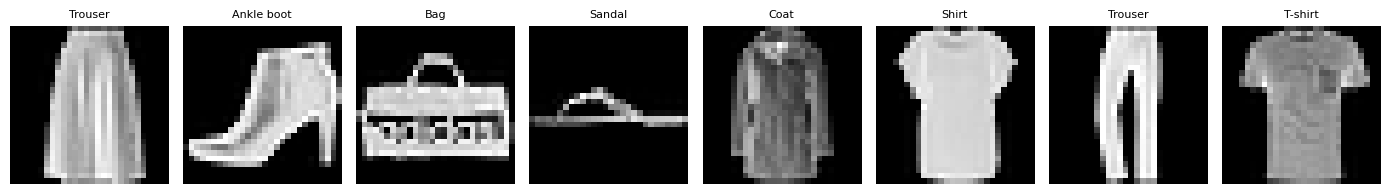

In [6]:
# Visualise a few samples
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(classes[labels[i]], fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()


## Step 2 — Define your model
Use `nn.Sequential` or a custom `nn.Module`. The input is a flattened 28×28 = 784-dim vector. The output should have 10 values (one per class).

In [36]:
# TODO: Define your classifier here.
#
## Requirements:
##   - Input:  784 (flattened 28x28 image)
##   - Output: 10  (one logit per class)
##   - At least one hidden layer with ReLU activation
#
## Hint: use nn.Flatten() as the first layer to go from (batch, 1, 28, 28) -> (batch, 784)
#
class fashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.pipeline = nn.Sequential(
            nn.Flatten(),
            # --- Hidden Layer 1 ---
            nn.Linear(784, 128), 
            nn.ReLU(),
            
            # --- Hidden Layer 2 (NEW) ---
            # Takes the 128 outputs from above, condenses them to 64
            nn.Linear(128, 64),  
            nn.ReLU(),
            
            # --- Output Layer ---
            # Takes the 64 outputs from above, yields final 10 classes
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.pipeline(x)

## Step 3 — Train the model

In [37]:
# TODO: Set up the loss function and optimizer.
# Use nn.CrossEntropyLoss() and torch.optim.Adam with lr=0.001
#
model = fashionClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [38]:
# TODO: Write the training loop.
# Train for 10 epochs.
# After each epoch, print: Epoch | Train Loss
# Store losses in a list so you can plot them later.

# Structure reminder:
#   for epoch in range(10):
#       for images, labels in train_loader:
#           images = images  (already batched)
#           ...
#
losses = []
for epoch in range(10):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        y_pred = model(images)
        loss = loss_fn(y_pred, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    print(f"Epoch {epoch + 1}/10 | Train Loss: {epoch_loss:.4f}")

Epoch 1/10 | Train Loss: 0.5133
Epoch 2/10 | Train Loss: 0.3779
Epoch 3/10 | Train Loss: 0.3419
Epoch 4/10 | Train Loss: 0.3172
Epoch 5/10 | Train Loss: 0.2948
Epoch 6/10 | Train Loss: 0.2817
Epoch 7/10 | Train Loss: 0.2684
Epoch 8/10 | Train Loss: 0.2587
Epoch 9/10 | Train Loss: 0.2490
Epoch 10/10 | Train Loss: 0.2392


## Step 4 — Plot the loss curve

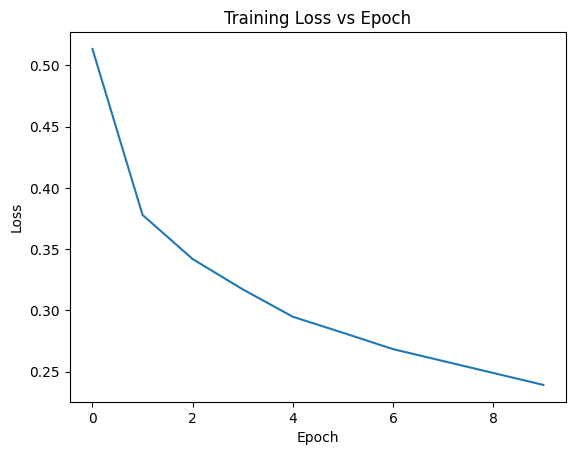

In [39]:
# TODO: Plot your training loss vs epoch.
# Label the axes and give the plot a title.
import matplotlib.pyplot as plt
epoch= list(range(10))
plt.plot(epoch, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.show()


## Step 5 — Evaluate on the test set

In [40]:
# TODO: Compute accuracy on the test set.
# Loop over test_loader, count correct predictions, divide by total.
# Print the final accuracy as a percentage.
#
# Hint: use torch.no_grad() during evaluation — no need to compute gradients.
# Hint: predictions = logits.argmax(dim=1)
#
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        y_pred = model(images)
        predicted_labels = y_pred.argmax(dim=1)
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 87.16%


## Bonus (optional)
- Add a validation split (use 10% of training data)
- Plot both train and validation loss on the same graph
- Try adding `nn.Dropout(0.3)` and see if it helps
- Report: what happens if you increase the batch size to 256?

## Submission checklist
- [ ] Model defined with at least one hidden layer
- [ ] Training loop runs for 10 epochs without errors
- [ ] Loss curve plotted
- [ ] Test accuracy >= 85% printed
- [ ] Code is clean and all TODOs filled in